# ApprOxiMate tutorial

## 1. Charge balancing

In [3]:
from approximate import charge_balance, oxidation_states, final_charge, parse_formula

In [4]:
ap = charge_balance("Na0.67Ni0.33Mn0.67O2")
ap

BalanceResult([Na+1:0.67, O-2:2.0, Ni+2:0.33, Mn+3:0.01, Mn+4:0.66], final_charge=0.0, is_balanced=True)

In [5]:
ap.final_charge, ap.is_balanced

(0.0, True)

In [6]:
print("Element", "Oxidation state", "Quantity", "SRP")
for s in ap.oxidation_states:
    print(s.element, s.oxidation_state, s.quantity, s.srp)

Element Oxidation state Quantity SRP
Na 1 0.67 None
O -2 2.0 None
Ni 2 0.33 -0.236
Mn 3 0.01 1.56
Mn 4 0.66 0.98


## 2. Output formats

In [7]:
str(ap)

'Na:1:0.67;O:-2:2.0;Ni:2:0.33;Mn:3:0.01;Mn:4:0.66;FinalChargeBalance:0.0'

In [8]:
ap.to_dataframe()

,Element,Oxidation_State,Quantity,Is_Fixed,SRP
0,Na,1,0.67,True,NaN
1,O,-2,2.00,True,NaN
2,Ni,2,0.33,False,-0.236
3,Mn,3,0.01,False,1.560
4,Mn,4,0.66,False,0.980


In [9]:
ap.to_dict()

{'elements': [{'element': 'Na',
   'oxidation_state': 1,
   'quantity': 0.67,
   'is_fixed': True,
   'srp': None},
  {'element': 'O',
   'oxidation_state': -2,
   'quantity': 2.0,
   'is_fixed': True,
   'srp': None},
  {'element': 'Ni',
   'oxidation_state': 2,
   'quantity': 0.33,
   'is_fixed': False,
   'srp': -0.236},
  {'element': 'Mn',
   'oxidation_state': 3,
   'quantity': 0.01,
   'is_fixed': False,
   'srp': 1.56},
  {'element': 'Mn',
   'oxidation_state': 4,
   'quantity': 0.66,
   'is_fixed': False,
   'srp': 0.98}],
 'final_charge': 0.0,
 'formula_string': 'Na:1:0.67;O:-2:2.0;Ni:2:0.33;Mn:3:0.01;Mn:4:0.66;FinalChargeBalance:0.0',
 'is_balanced': True}

## 3. Mixed valence, fractions and unbalanceable formulas

In [10]:
charge_balance("Fe3O4").to_dataframe()

,Element,Oxidation_State,Quantity,Is_Fixed,SRP
0,O,-2,4.0,True,NaN
1,Fe,2,1.0,False,-0.440
2,Fe,3,2.0,False,0.771


In [11]:
charge_balance("NaNi1/3Mn2/3O2").to_dataframe()

,Element,Oxidation_State,Quantity,Is_Fixed,SRP
0,Na,1,1.000,True,NaN
1,O,-2,2.000,True,NaN
2,Ni,2,0.333,False,-0.236
3,Mn,3,0.333,False,1.560
4,Mn,4,0.334,False,0.980


In [12]:
charge_balance({"Na": 0.5, "Mn": 1, "O": 2})

BalanceResult([Na+1:0.5, O-2:2.0, Mn+3:0.5, Mn+4:0.5], final_charge=0.0, is_balanced=True)

In [13]:
ap = charge_balance("Na3O")
ap.final_charge, ap.is_balanced

(1.0, False)

In [14]:
charge_balance("Xx2O") is None

True

## 4. Shortcuts

In [15]:
oxidation_states("LiFePO4")

[ElementState(element='Li', oxidation_state=1, quantity=1.0, is_fixed=True, srp=None),
 ElementState(element='P', oxidation_state=5, quantity=1.0, is_fixed=True, srp=-0.377),
 ElementState(element='O', oxidation_state=-2, quantity=4.0, is_fixed=True, srp=None),
 ElementState(element='Fe', oxidation_state=2, quantity=1.0, is_fixed=False, srp=-0.44)]

In [16]:
oxidation_states("LiFePO4", as_dataframe=True)

,Element,Oxidation_State,Quantity,Is_Fixed,SRP
0,Li,1,1.0,True,NaN
1,P,5,1.0,True,-0.377
2,O,-2,4.0,True,NaN
3,Fe,2,1.0,False,-0.440


In [17]:
final_charge("NaMn0.5Ni0.5O2")

0.0

In [18]:
parse_formula("Na2/3Mn2/3Ni1/3O2")

{'Na': 0.666667, 'Mn': 0.666667, 'Ni': 0.333333, 'O': 2.0}

## 5. Many formulas at once

In [19]:
import pandas as pd

formulas = ["NaCl", "LiCoO2", "Fe3O4", "KMnO4", "NaMn0.5Ni0.5O2", "Na3O", "CuZn"]

pd.DataFrame([
    {"formula": f, "final_charge": ap.final_charge, "balanced": ap.is_balanced, "result": str(r)}
    for f in formulas
    for r in [charge_balance(f)]
])

,formula,final_charge,balanced,result
0,NaCl,1.0,False,Cl:-1:1.0;Na:1:1.0;FinalChargeBalance:0.0
1,LiCoO2,1.0,False,Li:1:1.0;O:-2:2.0;Co:3:1.0;FinalChargeBalance:0.0
2,Fe3O4,1.0,False,O:-2:4.0;Fe:2:1.0;Fe:3:2.0;FinalChargeBalance:0.0
3,KMnO4,1.0,False,K:1:1.0;O:-2:4.0;Mn:7:1.0;FinalChargeBalance:0.0
4,NaMn0.5Ni0.5O2,1.0,False,Na:1:1.0;O:-2:2.0;Ni:2:0.5;Mn:4:0.5;FinalCharg...
5,Na3O,1.0,False,Na:1:3.0;O:-2:1.0;FinalChargeBalance:1.0
6,CuZn,1.0,False,Cu:0:1.0;Zn:0:1.0;FinalChargeBalance:0.0


## 6. Capacity

In [20]:
from approximate import capacity, molar_mass

cap = capacity("NaNi1/3Mn2/3O2")
cap

CapacityResult(alkali='Na', full=1.0, removable=1.0, remaining=0.0, molar_mass=111.177597361548, q_theoretical=241.06908028679916, q_adjusted=241.06908028679916)

In [21]:
cap.q_theoretical, cap.q_adjusted, cap.removable, cap.remaining

(241.06908028679916, 241.06908028679916, 1.0, 0.0)

In [22]:
molar_mass("NaNi1/3Mn2/3O2")

111.177597361548

In [23]:
cathodes = ["NaFeO2", "NaMnO2", "NaNi0.5Mn0.5O2", "Na0.67Ni0.33Mn0.67O2", "LiFePO4", "LiCoO2"]

pd.DataFrame([{"formula": f, **capacity(f).to_dict()} for f in cathodes]).round(2)

,formula,alkali,full,removable,remaining,molar_mass,q_theoretical,q_adjusted
0,NaFeO2,Na,1.00,0.00,1.0,110.83,241.82,0.00
1,NaMnO2,Na,1.00,1.00,0.0,109.93,243.81,243.81
2,NaNi0.5Mn0.5O2,Na,1.00,1.00,0.0,111.80,239.72,239.72
3,Na0.67Ni0.33Mn0.67O2,Na,0.67,0.67,0.0,103.58,173.37,173.37
4,LiFePO4,Li,1.00,1.00,0.0,157.75,169.89,169.89
5,LiCoO2,Li,1.00,1.00,0.0,97.87,273.84,273.84


In [24]:
capacity("LiNaFe2O4", alkali="Na")

CapacityResult(alkali='Na', full=1.0, removable=0.0, remaining=1.0, molar_mass=205.61576928000002, q_theoretical=130.34740106896749, q_adjusted=0.0)

In [25]:
try:
    capacity("LiFePO4", alkali="Na")
except ValueError as e:
    print(e)

Na not found in formula


## 7. Alkali sweeps

In [26]:
from approximate import alkali_sweep

sweep = alkali_sweep("NaNi1/3Mn2/3O2", interval=0.1)
sweep.to_dataframe().round(3)

,Na,final_charge,Mn_avg,Ni_avg,Mn+3,Mn+4,Ni+2,Ni+3,Ni+4
0,0.1,0.0,4.000,3.700,0.000,0.667,0.000,0.100,0.233
1,0.2,0.0,4.000,3.399,0.000,0.667,0.000,0.200,0.133
2,0.3,0.0,4.000,3.099,0.000,0.667,0.000,0.300,0.033
3,0.4,0.0,4.000,2.799,0.000,0.667,0.067,0.266,0.000
4,0.5,0.0,4.000,2.498,0.000,0.667,0.167,0.166,0.000
5,0.6,0.0,4.000,2.198,0.000,0.667,0.267,0.066,0.000
6,0.7,0.0,3.951,2.000,0.033,0.634,0.333,0.000,0.000
7,0.8,0.0,3.801,2.000,0.133,0.534,0.333,0.000,0.000
8,0.9,0.0,3.651,2.000,0.233,0.434,0.333,0.000,0.000


In [27]:
sweep.oxidation_states[("Ni", 2)]

array([0.   , 0.   , 0.   , 0.067, 0.167, 0.267, 0.333, 0.333, 0.333])

## 8. Plotting

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from approximate.plotting import (plot_charge_balance, plot_substitution,
                                  plot_average_oxidation_states, plot_oxidation_states)

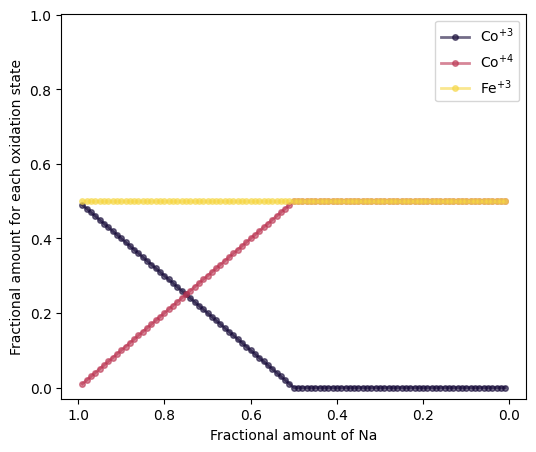

In [29]:
plot_oxidation_states("NaCo0.5Fe0.5O2", cmap="inferno");

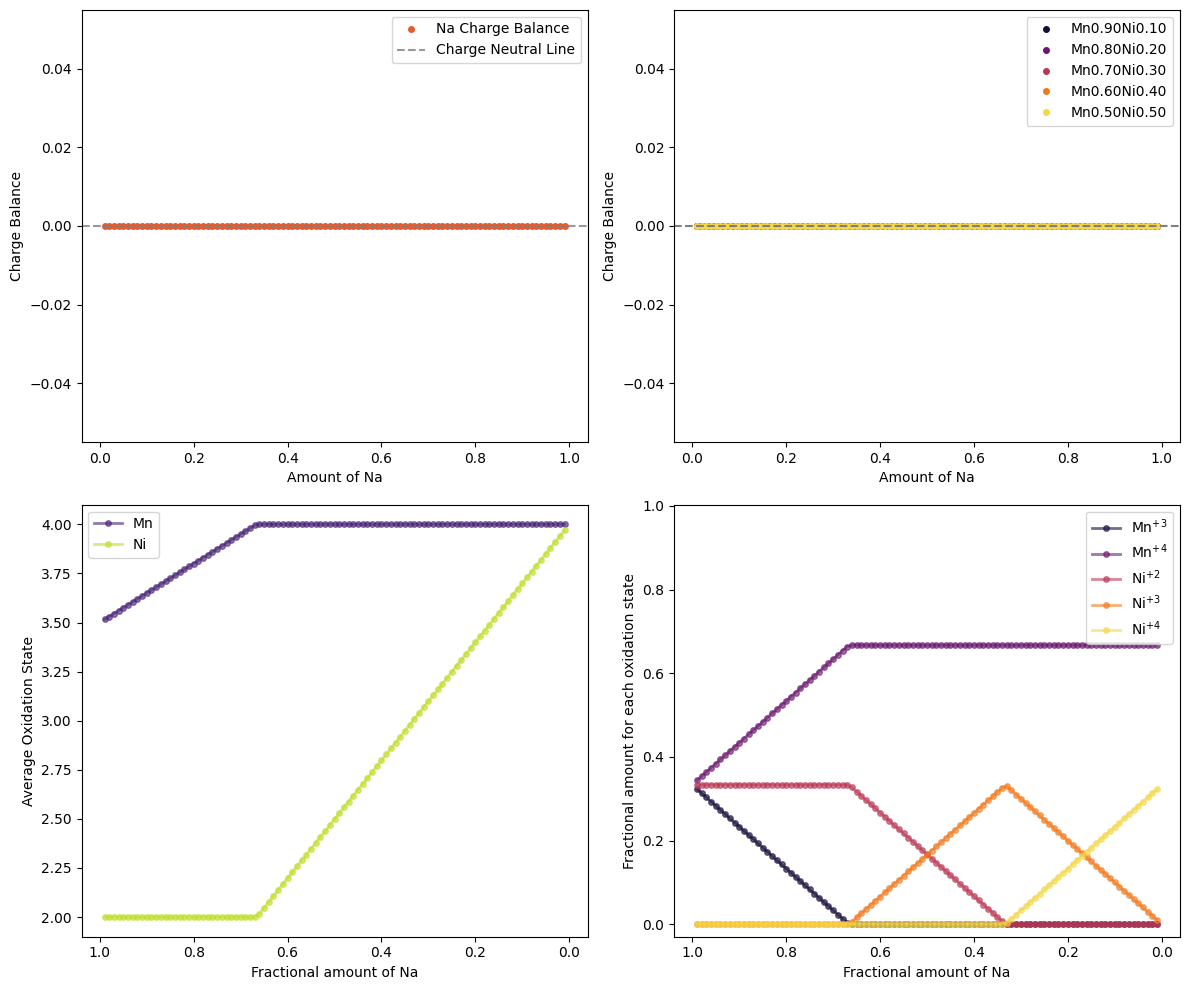

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_charge_balance("NaNi1/3Mn2/3O2", ax=axes[0, 0])
plot_substitution("NaMnO2", "Mn", "Ni", np.linspace(0.1, 0.5, 5), ax=axes[0, 1], cmap="inferno")
plot_average_oxidation_states("NaNi1/3Mn2/3O2", ax=axes[1, 0])
plot_oxidation_states("NaNi1/3Mn2/3O2", ax=axes[1, 1], cmap="inferno")

fig.tight_layout()

## 9. Feature engineering

In [31]:
from approximate.feature_engineering import MaterialFeatureExtractor

extractor = MaterialFeatureExtractor(mode="both")
features = pd.DataFrame(extractor.featurize_many(["NaMn0.5Ni0.5O2", "LiFePO4", "Fe3O4"]))
features.shape

(3, 449)

In [32]:
features.iloc[:, :8]

,formula,all_valence_s_sum,all_valence_s_avg,all_valence_s_dev,all_valence_s_min,all_valence_s_max,all_valence_s_range,all_valence_s_mode
0,NaMn0.5Ni0.5O2,4.0,1.000000,1.000000,0.0,2.0,2.0,0.0
1,LiFePO4,8.0,1.142857,0.989743,0.0,2.0,2.0,2.0
2,Fe3O4,8.0,1.142857,0.989743,0.0,2.0,2.0,2.0
